# Customer Segmentation using Unsupervised Learning
## Practical Exam – Set A | Online Retail II

**Objective:** UK customer segmentation using RFM and comparison of K-Means, Agglomerative Clustering and DBSCAN.

### Intuition
Customer segmentation groups customers with similar buying behaviour. RFM summarizes **how recently**, **how often**, and **how much** a customer buys.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram
import joblib

paths=[Path("online_retail_II(1).csv"),Path("online_retail_II.csv"),Path("/mnt/data/online_retail_II(1).csv")]
file_path=next((p for p in paths if p.exists()),None)
if file_path is None: raise FileNotFoundError("CSV not found")
df=pd.read_csv(file_path)
print("Shape:",df.shape)
print(df.info())
display(df.head(10))

Shape: (1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


# Step 1 – Data Loading, Cleaning & EDA
### Intuition
Before clustering, invalid transactions and missing customer IDs must be removed. EDA helps understand sales, orders and customer concentration.

In [2]:
df=df.rename(columns={"Invoice":"InvoiceNo","Price":"UnitPrice","Customer ID":"CustomerID"})
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])

uk=df[df["Country"].eq("United Kingdom")].copy()
print("UK rows:",len(uk))

n=len(uk); uk=uk.dropna(subset=["CustomerID"]); print("After CustomerID removal:",len(uk)," Removed:",n-len(uk))
n=len(uk); uk=uk[uk["Quantity"]>0]; print("After Quantity > 0:",len(uk)," Removed:",n-len(uk))
n=len(uk); uk=uk[uk["UnitPrice"]>0]; print("After UnitPrice > 0:",len(uk)," Removed:",n-len(uk))

uk["TotalPrice"]=uk["Quantity"]*uk["UnitPrice"]
print("Final cleaned rows:",len(uk))
display(uk.head())

UK rows: 981330
After CustomerID removal: 741301  Removed: 240029
After Quantity > 0: 725296  Removed: 16005
After UnitPrice > 0: 725250  Removed: 46
Final cleaned rows: 725250


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


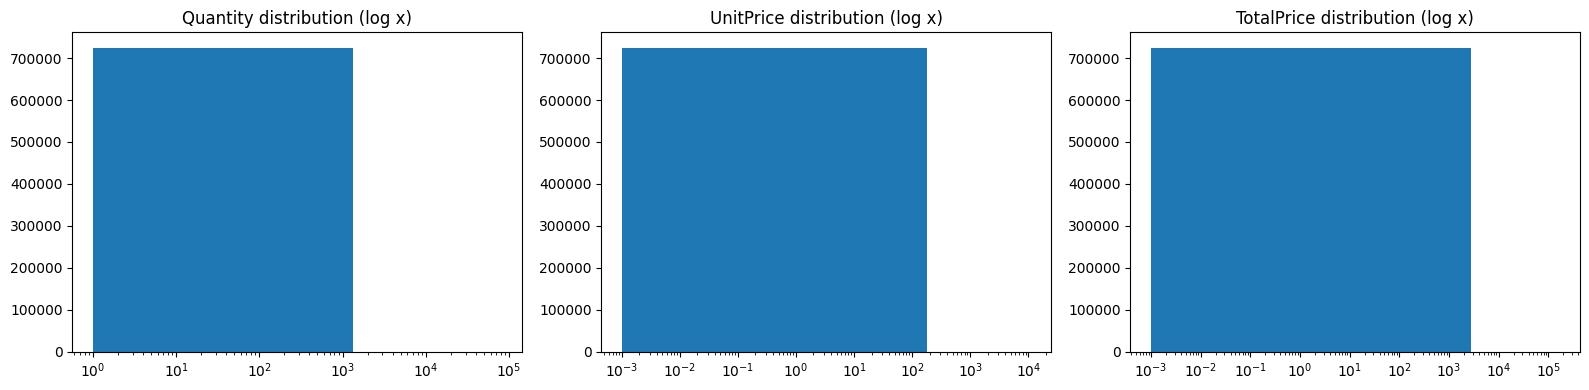

,Order_Count
Country,
United Kingdom,49108
Germany,1095
EIRE,806
France,746
Netherlands,250
Spain,188
Belgium,183
Sweden,129
Portugal,124


,Transactions
InvoiceDate,
2009-12-01,1429
2010-01-01,906
2010-02-01,1001
2010-03-01,1396
2010-04-01,1222
2010-05-01,1270
2010-06-01,1377
2010-07-01,1272
2010-08-01,1193


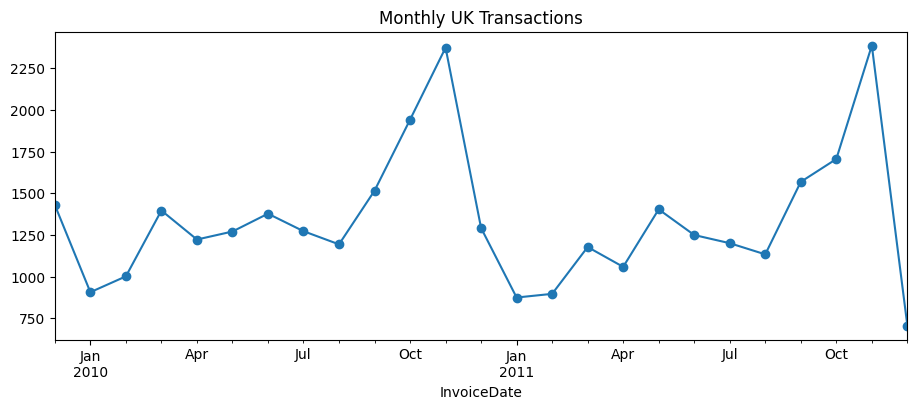

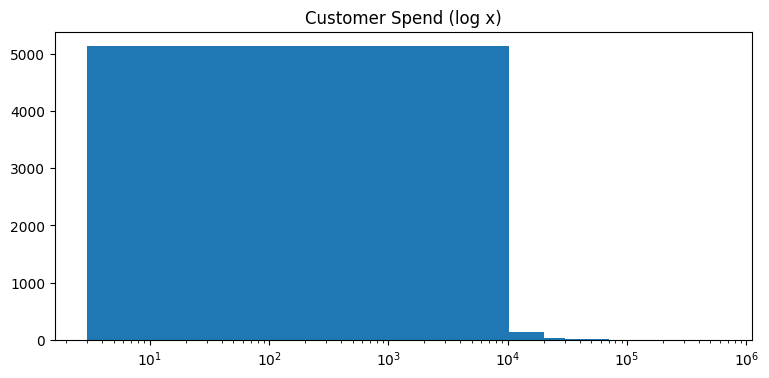

,Frequency
CustomerID,
12748.0,336
17841.0,211
15311.0,208
13089.0,203
14606.0,192
17850.0,155
18102.0,145
13694.0,143
15061.0,127


Unique customers: 5350
Customers driving 80% revenue: 1301 (24.32%)


In [3]:
fig,ax=plt.subplots(1,3,figsize=(16,4))
for a,c in zip(ax,["Quantity","UnitPrice","TotalPrice"]):
    a.hist(uk[c],bins=60); a.set_xscale("log"); a.set_title(c+" distribution (log x)")
plt.tight_layout(); plt.show()

top10=df.groupby("Country")["InvoiceNo"].nunique().sort_values(ascending=False).head(10)
display(top10.to_frame("Order_Count"))

monthly=uk.set_index("InvoiceDate").resample("MS")["InvoiceNo"].nunique()
display(monthly.to_frame("Transactions"))
monthly.plot(figsize=(11,4),marker="o",title="Monthly UK Transactions"); plt.show()

spend=uk.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False)
plt.figure(figsize=(9,4)); plt.hist(spend,bins=60); plt.xscale("log"); plt.title("Customer Spend (log x)"); plt.show()

display(uk.groupby("CustomerID")["InvoiceNo"].nunique().sort_values(ascending=False).head(10).to_frame("Frequency"))
print("Unique customers:",spend.size)

cum=spend.cumsum()/spend.sum()*100
n80=int((cum<80).sum()+1)
print(f"Customers driving 80% revenue: {n80} ({100*n80/len(spend):.2f}%)")

# Step 2 – RFM Feature Engineering
### Intuition
**Recency** = days since last purchase. **Frequency** = unique invoices. **Monetary** = total spend. These three features describe customer value and activity.

In [4]:
snapshot=pd.Timestamp("2011-12-31")
rfm=uk.groupby("CustomerID").agg(
    Recency=("InvoiceDate",lambda x:(snapshot-x.max()).days),
    Frequency=("InvoiceNo","nunique"),
    Monetary=("TotalPrice","sum")
).reset_index()
display(rfm.head(10))
display(rfm[["Recency","Frequency","Monetary"]].describe())

,CustomerID,Recency,Frequency,Monetary
0,12346.0,346,12,77556.46
1,12608.0,425,1,415.79
2,12745.0,507,2,723.85
3,12746.0,561,1,254.55
4,12747.0,23,26,9276.54
5,12748.0,21,336,56599.39
6,12749.0,24,9,6897.36
7,12777.0,478,1,519.45
8,12819.0,479,1,540.52
9,12820.0,24,11,2689.52


,Recency,Frequency,Monetary
count,5350.000000,5350.000000,5350.000000
mean,223.546168,6.269346,2751.990190
std,209.973818,11.995550,12080.466564
min,21.000000,1.000000,2.950000
25%,46.000000,1.000000,336.167500
50%,119.000000,3.000000,849.910000
75%,402.000000,7.000000,2214.905000
max,759.000000,336.000000,608821.650000


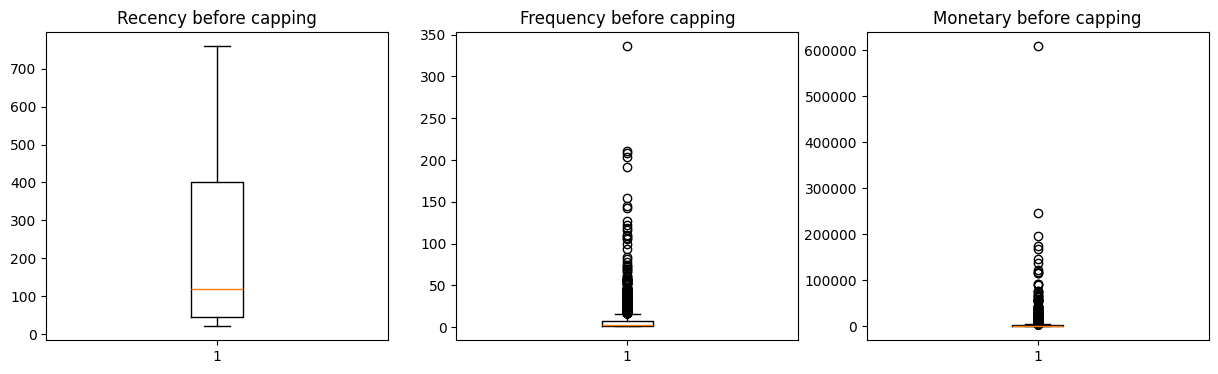

Caps: {'Recency': 1470.0, 'Frequency': 25.0, 'Monetary': 7851.1175}


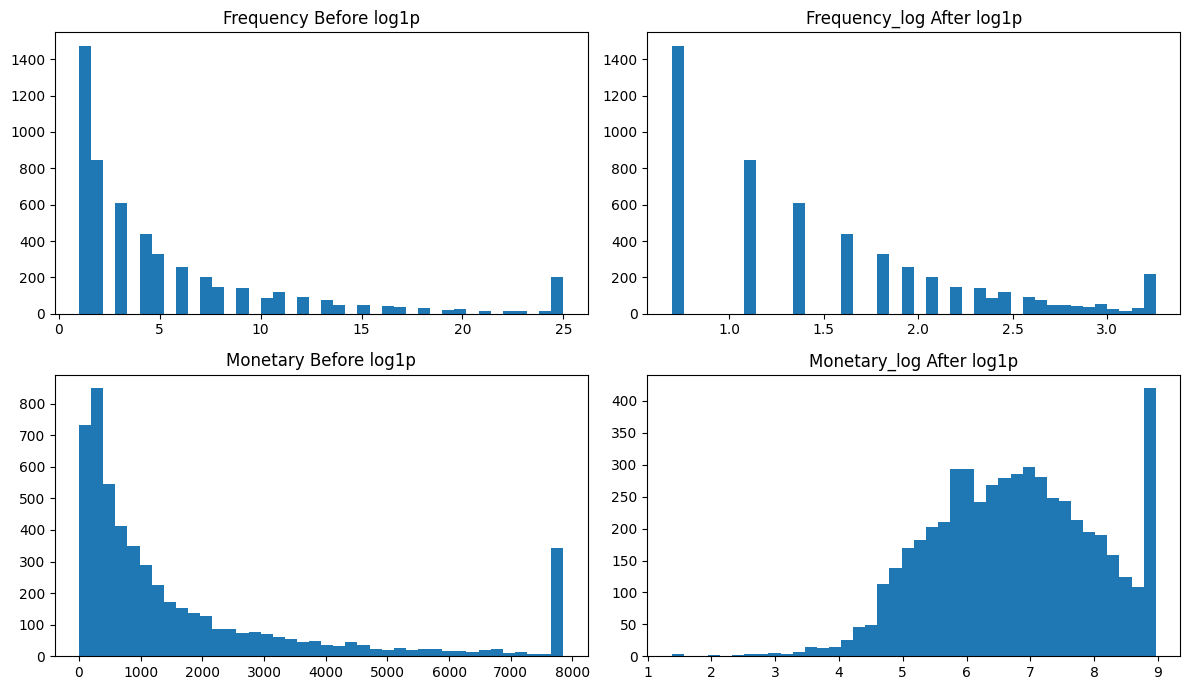

In [5]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
for a,c in zip(ax,["Recency","Frequency","Monetary"]): a.boxplot(rfm[c]); a.set_title(c+" before capping")
plt.show()

rfm_c=rfm.copy()
caps={}
for c in ["Recency","Frequency","Monetary"]:
    q1,q3=rfm_c[c].quantile([.25,.75]); upper=q3+3*(q3-q1); caps[c]=upper
    rfm_c[c]=rfm_c[c].clip(upper=upper)
rfm_c["Frequency_log"]=np.log1p(rfm_c["Frequency"])
rfm_c["Monetary_log"]=np.log1p(rfm_c["Monetary"])
print("Caps:",caps)

fig,ax=plt.subplots(2,2,figsize=(12,7))
for a,c,t in [(ax[0,0],"Frequency","Before log1p"),(ax[0,1],"Frequency_log","After log1p"),
              (ax[1,0],"Monetary","Before log1p"),(ax[1,1],"Monetary_log","After log1p")]:
    a.hist(rfm_c[c],bins=40); a.set_title(c+" "+t)
plt.tight_layout(); plt.show()

In [6]:
features=["Recency","Frequency_log","Monetary_log"]
scaler=StandardScaler()
X=scaler.fit_transform(rfm_c[features])
print("Means:",np.round(X.mean(axis=0),4))
print("Std:",np.round(X.std(axis=0),4))
print("Raw RFM is not used for clustering; scaled transformed RFM is used.")

Means: [-0.  0.  0.]
Std: [1. 1. 1.]
Raw RFM is not used for clustering; scaled transformed RFM is used.


# Step 3 – K-Means
### Intuition
K-Means assigns customers to the nearest centroid. We test k=2–10 using inertia and silhouette.

**Selected k = 4:** k=2 has the highest silhouette, but k=4 gives a more useful business-level segmentation and an elbow-style trade-off.

,k,Inertia,Silhouette
0,2,7644.706253,0.433091
1,3,4903.889426,0.409523
2,4,3773.791621,0.373525
3,5,2969.205917,0.383819
4,6,2562.196718,0.353965
5,7,2258.052194,0.345668
6,8,2056.307509,0.345983
7,9,1874.773638,0.321326
8,10,1748.593656,0.316991


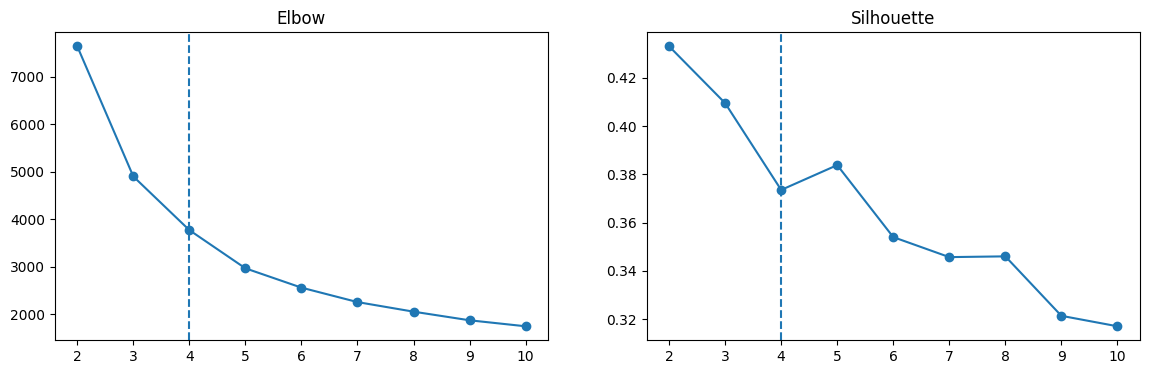

In [7]:
rows=[]
for k in range(2,11):
    m=KMeans(n_clusters=k,init="k-means++",n_init=10,random_state=42)
    lab=m.fit_predict(X)
    rows.append([k,m.inertia_,silhouette_score(X,lab)])
km_eval=pd.DataFrame(rows,columns=["k","Inertia","Silhouette"])
display(km_eval)

fig,ax=plt.subplots(1,2,figsize=(14,4))
ax[0].plot(km_eval.k,km_eval.Inertia,"o-"); ax[0].axvline(4,ls="--"); ax[0].set_title("Elbow")
ax[1].plot(km_eval.k,km_eval.Silhouette,"o-"); ax[1].axvline(4,ls="--"); ax[1].set_title("Silhouette")
plt.show()

KMeans_Cluster
0    1109
1    1138
2    1419
3    1684
Name: count, dtype: int64

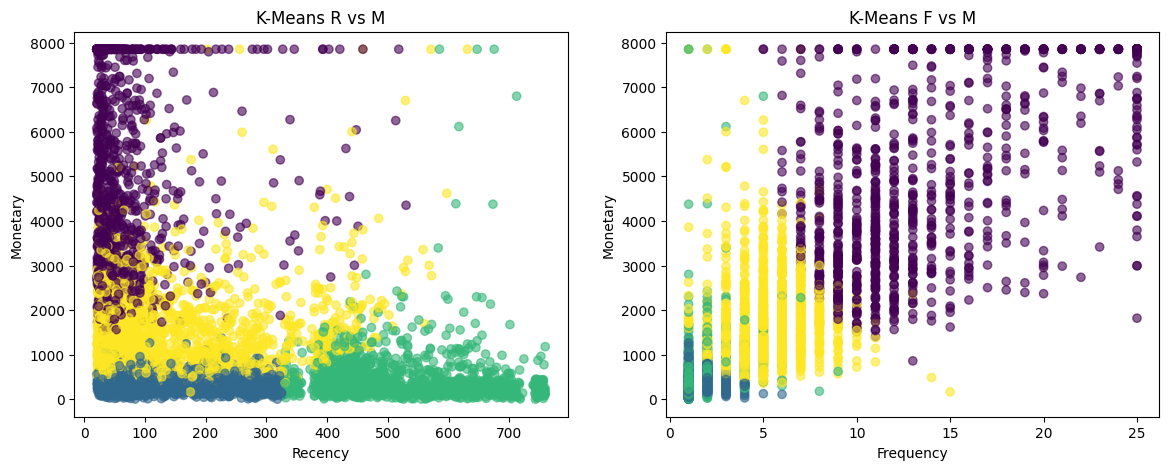

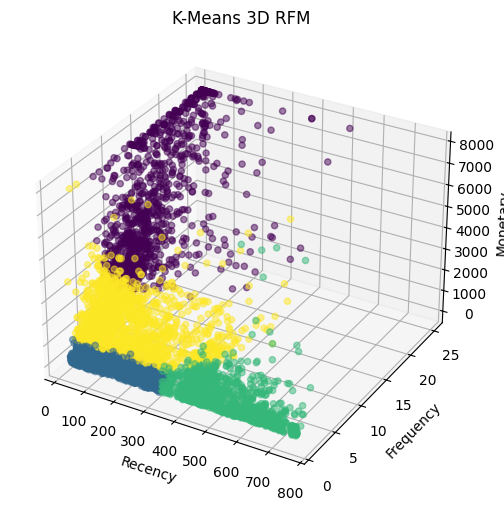

,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,65.120830,15.138864,5232.563763
3,139.804632,4.774941,1551.429702
2,521.002114,1.606765,455.246831
1,130.949033,1.636204,362.880000


In [8]:
k_optimal=4
kmeans=KMeans(n_clusters=4,init="k-means++",n_init=20,max_iter=500,random_state=42)
rfm_c["KMeans_Cluster"]=kmeans.fit_predict(X)
display(rfm_c["KMeans_Cluster"].value_counts().sort_index())

fig,ax=plt.subplots(1,2,figsize=(14,5))
ax[0].scatter(rfm_c.Recency,rfm_c.Monetary,c=rfm_c.KMeans_Cluster,alpha=.6); ax[0].set(xlabel="Recency",ylabel="Monetary",title="K-Means R vs M")
ax[1].scatter(rfm_c.Frequency,rfm_c.Monetary,c=rfm_c.KMeans_Cluster,alpha=.6); ax[1].set(xlabel="Frequency",ylabel="Monetary",title="K-Means F vs M")
plt.show()

fig=plt.figure(figsize=(9,6)); a=fig.add_subplot(111,projection="3d")
a.scatter(rfm_c.Recency,rfm_c.Frequency,rfm_c.Monetary,c=rfm_c.KMeans_Cluster,alpha=.5)
a.set(xlabel="Recency",ylabel="Frequency",zlabel="Monetary",title="K-Means 3D RFM"); plt.show()

km_profile=rfm_c.groupby("KMeans_Cluster")[["Recency","Frequency","Monetary"]].mean().sort_values("Monetary",ascending=False)
display(km_profile)

### K-Means Personas
- **Champions:** recent, frequent and high-value.
- **Loyal Customers:** regular buyers with meaningful spend.
- **At-Risk / Hibernating:** long recency and low frequency.
- **Low-Engagement:** low frequency and lower monetary value.

### Intuition
Cluster means turn mathematical groups into understandable marketing personas.

In [9]:
persona_map={0:"Champions",3:"Loyal Customers",2:"At-Risk / Hibernating",1:"Low-Engagement Customers"}
km_profile["Persona"]=km_profile.index.map(persona_map)
display(km_profile)

,Recency,Frequency,Monetary,Persona
KMeans_Cluster,,,,
0,65.120830,15.138864,5232.563763,Champions
3,139.804632,4.774941,1551.429702,Loyal Customers
2,521.002114,1.606765,455.246831,At-Risk / Hibernating
1,130.949033,1.636204,362.880000,Low-Engagement Customers


# Step 4 – Agglomerative Hierarchical Clustering
### Intuition
Agglomerative clustering starts with individual customers and repeatedly merges similar groups. A dendrogram shows the hierarchy.

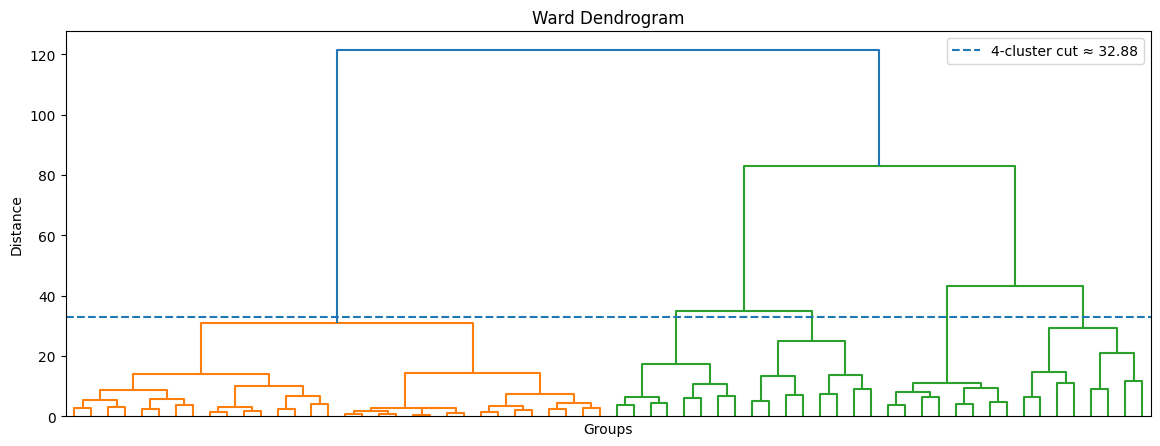

4-cluster threshold: 32.87660680582281


In [10]:
Z=linkage(X,method="ward")
threshold_4=(Z[-5,2]+Z[-4,2])/2
plt.figure(figsize=(14,5))
dendrogram(Z,truncate_mode="level",p=5,no_labels=True)
plt.axhline(threshold_4,ls="--",label=f"4-cluster cut ≈ {threshold_4:.2f}")
plt.legend(); plt.title("Ward Dendrogram"); plt.xlabel("Groups"); plt.ylabel("Distance"); plt.show()
print("4-cluster threshold:",threshold_4)

,Clusters,Linkage,Silhouette
0,3,ward,0.385891
1,3,complete,0.326480
2,3,average,0.321314
3,4,ward,0.370783
4,4,complete,0.307473
5,4,average,0.363873
6,5,ward,0.298087
7,5,complete,0.284338
8,5,average,0.341765


,Recency,Frequency,Monetary
Agg_Cluster,,,
0,109.342180,2.994787,824.218595
1,77.812500,12.909946,4498.759183
2,495.404321,1.246142,291.197308
3,454.892544,4.008772,1455.760779


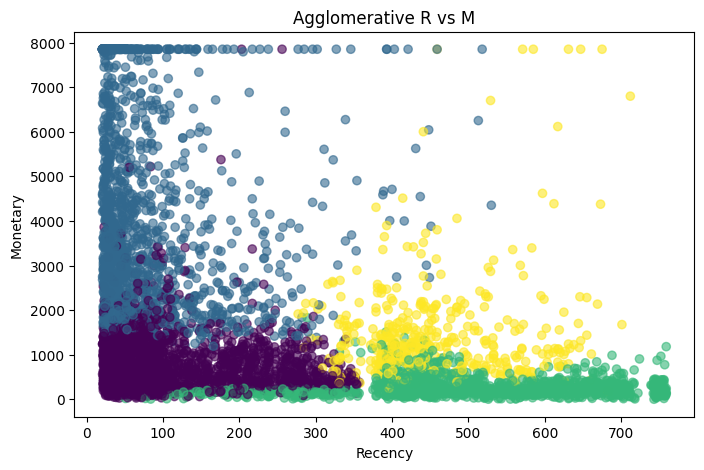

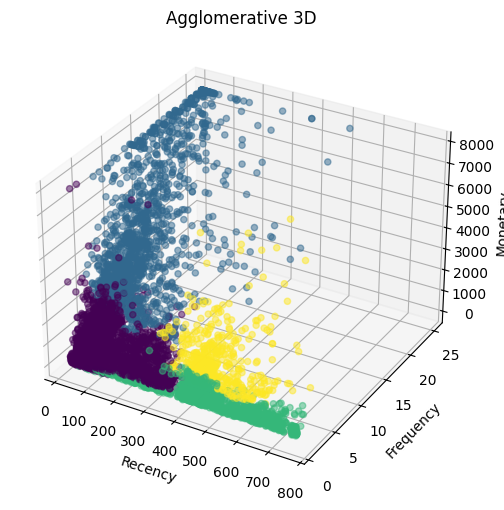

In [11]:
ar=[]
for n in [3,4,5]:
    for link in ["ward","complete","average"]:
        m=AgglomerativeClustering(n_clusters=n,linkage=link)
        lab=m.fit_predict(X)
        ar.append([n,link,silhouette_score(X,lab)])
agg_eval=pd.DataFrame(ar,columns=["Clusters","Linkage","Silhouette"])
display(agg_eval)

agg=AgglomerativeClustering(n_clusters=4,linkage="ward")
rfm_c["Agg_Cluster"]=agg.fit_predict(X)
display(rfm_c.groupby("Agg_Cluster")[["Recency","Frequency","Monetary"]].mean())

plt.figure(figsize=(8,5)); plt.scatter(rfm_c.Recency,rfm_c.Monetary,c=rfm_c.Agg_Cluster,alpha=.6)
plt.title("Agglomerative R vs M"); plt.xlabel("Recency"); plt.ylabel("Monetary"); plt.show()

fig=plt.figure(figsize=(9,6)); a=fig.add_subplot(111,projection="3d")
a.scatter(rfm_c.Recency,rfm_c.Frequency,rfm_c.Monetary,c=rfm_c.Agg_Cluster,alpha=.5)
a.set(xlabel="Recency",ylabel="Frequency",zlabel="Monetary",title="Agglomerative 3D"); plt.show()

# Step 5 – DBSCAN
### Intuition
DBSCAN finds dense regions and identifies isolated observations as **noise**. It does not require a fixed number of clusters.

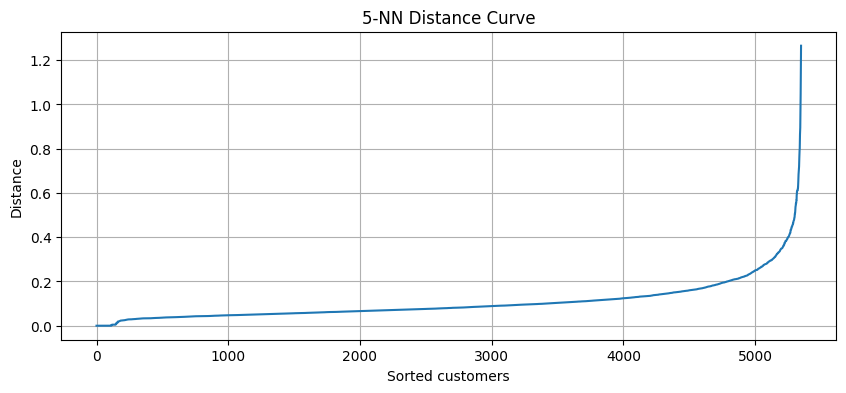

,eps,min_samples,clusters,noise,noise_pct,Silhouette
0,0.3,3,7,86,1.607477,0.005152
1,0.3,5,5,130,2.429907,0.105491
2,0.3,8,3,194,3.626168,0.198689
3,0.3,10,3,236,4.411215,0.201054
4,0.5,3,3,17,0.317757,0.304084
5,0.5,5,2,26,0.485981,0.333463
6,0.5,8,2,39,0.728972,0.333440
7,0.5,10,2,41,0.766355,0.333265
8,0.7,3,1,4,0.074766,NaN
9,0.7,5,1,6,0.112150,NaN


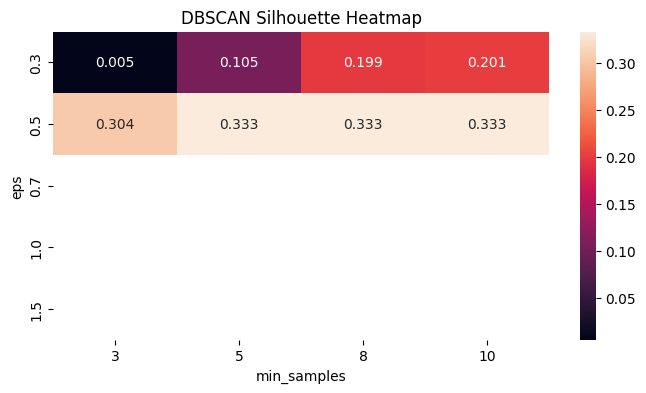

In [12]:
nn=NearestNeighbors(n_neighbors=5).fit(X)
dist,_=nn.kneighbors(X)
kdist=np.sort(dist[:,-1])
plt.figure(figsize=(10,4)); plt.plot(kdist); plt.title("5-NN Distance Curve"); plt.xlabel("Sorted customers"); plt.ylabel("Distance"); plt.grid(); plt.show()

grid=[]
for eps in [0.3,0.5,0.7,1.0,1.5]:
    for ms in [3,5,8,10]:
        m=DBSCAN(eps=eps,min_samples=ms,metric="euclidean")
        lab=m.fit_predict(X); mask=lab!=-1
        nc=len(set(lab[mask])); noise=(lab==-1).sum()
        sil=silhouette_score(X[mask],lab[mask]) if nc>=2 else np.nan
        grid.append([eps,ms,nc,noise,100*noise/len(lab),sil])
db_grid=pd.DataFrame(grid,columns=["eps","min_samples","clusters","noise","noise_pct","Silhouette"])
display(db_grid)

plt.figure(figsize=(8,4)); sns.heatmap(db_grid.pivot(index="eps",columns="min_samples",values="Silhouette"),annot=True,fmt=".3f")
plt.title("DBSCAN Silhouette Heatmap"); plt.show()

Selected: 0.5 5
Clusters: 2
Noise points: 26
Noise %: 0.49


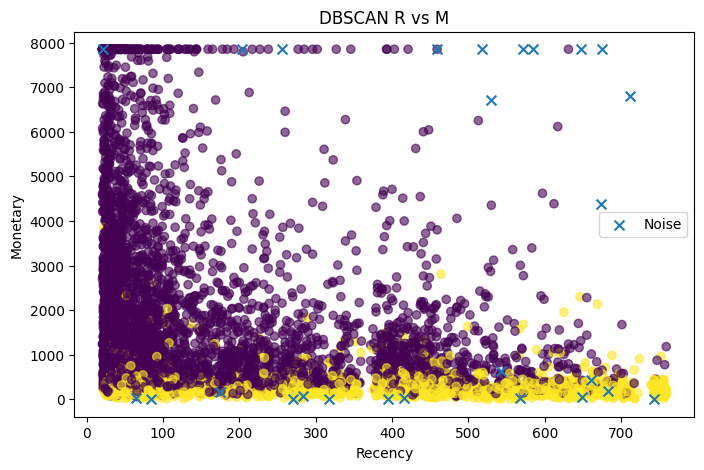

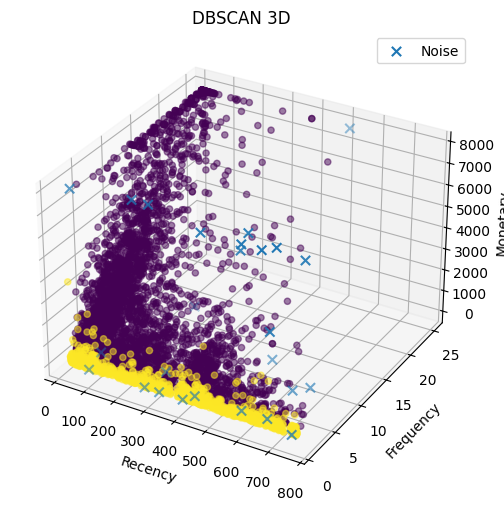

,Recency,Frequency,Monetary
DBSCAN_Cluster,,,
0,163.052863,7.100026,2316.995172
1,378.873720,1.000000,302.378922


Noise interpretation: unusual RFM combinations are kept outside the normal dense customer groups.


In [13]:
best=db_grid.dropna().sort_values("Silhouette",ascending=False).iloc[0]
eps_opt=float(best.eps); ms_opt=int(best.min_samples)
db=DBSCAN(eps=eps_opt,min_samples=ms_opt,metric="euclidean")
rfm_c["DBSCAN_Cluster"]=db.fit_predict(X)
lab=rfm_c.DBSCAN_Cluster
mask=lab!=-1
print("Selected:",eps_opt,ms_opt)
print("Clusters:",len(set(lab[mask])))
print("Noise points:",(lab==-1).sum())
print("Noise %:",round(100*(lab==-1).mean(),2))

plt.figure(figsize=(8,5))
plt.scatter(rfm_c.loc[mask,"Recency"],rfm_c.loc[mask,"Monetary"],c=lab[mask],alpha=.6)
plt.scatter(rfm_c.loc[~mask,"Recency"],rfm_c.loc[~mask,"Monetary"],marker="x",s=50,label="Noise")
plt.legend(); plt.title("DBSCAN R vs M"); plt.xlabel("Recency"); plt.ylabel("Monetary"); plt.show()

fig=plt.figure(figsize=(9,6)); a=fig.add_subplot(111,projection="3d")
a.scatter(rfm_c.loc[mask,"Recency"],rfm_c.loc[mask,"Frequency"],rfm_c.loc[mask,"Monetary"],c=lab[mask],alpha=.5)
a.scatter(rfm_c.loc[~mask,"Recency"],rfm_c.loc[~mask,"Frequency"],rfm_c.loc[~mask,"Monetary"],marker="x",s=45,label="Noise")
a.set(xlabel="Recency",ylabel="Frequency",zlabel="Monetary",title="DBSCAN 3D"); a.legend(); plt.show()

display(rfm_c[mask].groupby("DBSCAN_Cluster")[["Recency","Frequency","Monetary"]].mean())
print("Noise interpretation: unusual RFM combinations are kept outside the normal dense customer groups.")

# Step 6 – Algorithm Comparison
### Intuition
Use several metrics together:
- **Silhouette:** higher is better.
- **Davies-Bouldin:** lower is better.
- **Calinski-Harabasz:** higher is better.
- DBSCAN also reports noise points.

In [14]:
def metrics(X,labels,name,params):
    m=labels!=-1; y=labels[m]; xx=X[m]; nc=len(set(y))
    return [name,params,nc,silhouette_score(xx,y),davies_bouldin_score(xx,y),calinski_harabasz_score(xx,y),int((labels==-1).sum())]

comparison=pd.DataFrame([
metrics(X,rfm_c.KMeans_Cluster.to_numpy(),"K-Means","k=4, n_init=20, max_iter=500"),
metrics(X,rfm_c.Agg_Cluster.to_numpy(),"Agglomerative","n_clusters=4, linkage=ward"),
metrics(X,rfm_c.DBSCAN_Cluster.to_numpy(),"DBSCAN",f"eps={eps_opt}, min_samples={ms_opt}")
],columns=["Algorithm","Hyperparameters","Cluster Count","Silhouette","Davies-Bouldin","Calinski-Harabasz","Noise"])
display(comparison)

st=[]
for seed in [0,7,21,42,99]:
    m=KMeans(n_clusters=4,init="k-means++",n_init=20,max_iter=500,random_state=seed)
    st.append([seed,silhouette_score(X,m.fit_predict(X))])
st=pd.DataFrame(st,columns=["Seed","Silhouette"])
display(st)
print("Mean ± Std:",round(st.Silhouette.mean(),4),"+/-",round(st.Silhouette.std(ddof=1),4))

,Algorithm,Hyperparameters,Cluster Count,Silhouette,Davies-Bouldin,Calinski-Harabasz,Noise
0,K-Means,"k=4, n_init=20, max_iter=500",4,0.373523,0.905369,5796.965365,0
1,Agglomerative,"n_clusters=4, linkage=ward",4,0.370783,0.878563,4867.134687,0
2,DBSCAN,"eps=0.5, min_samples=5",2,0.333463,1.027160,3121.371615,26


,Seed,Silhouette
0,0,0.373530
1,7,0.373507
2,21,0.373469
3,42,0.373523
4,99,0.373518


Mean ± Std: 0.3735 +/- 0.0


## Business Recommendation
**Recommended operational model:** K-Means with 4 interpretable segments.

| Segment | Description | Suggested action |
|---|---|---|
| Champions | Recent, frequent, high spend | VIP rewards, early access, referrals |
| Loyal Customers | Regular valuable buyers | Cross-sell and upsell |
| At-Risk / Hibernating | Inactive and low frequency | Win-back offers and reminders |
| Low-Engagement | Low frequency/value | Activation campaigns |

**Additional data:** product preferences, demographics, acquisition channel, discount usage, returns, app/website engagement and geography.

### Intuition
RFM tells us what customers buy and how often. Extra behavioural and marketing data can make campaigns more targeted.

In [15]:
# Step 7 – Save model and predict new customers
joblib.dump(scaler,"rfm_scaler.pkl")
joblib.dump(kmeans,"kmeans_customer_segmentation.pkl")
print("Saved rfm_scaler.pkl and kmeans_customer_segmentation.pkl")

def predict_segment(recency,frequency,monetary):
    x=pd.DataFrame({"Recency":[recency],"Frequency_log":[np.log1p(frequency)],"Monetary_log":[np.log1p(monetary)]})
    label=int(kmeans.predict(scaler.transform(x[["Recency","Frequency_log","Monetary_log"]]))[0])
    return label,persona_map.get(label,"Customer Segment")

tests=pd.DataFrame([
["Customer A",25,20,6000],["Customer B",60,8,2200],
["Customer C",300,3,700],["Customer D",500,1,250],["Customer E",100,5,1500]
],columns=["Customer","Recency","Frequency","Monetary"])
tests[["Predicted_Cluster","Persona"]]=tests.apply(lambda r: pd.Series(predict_segment(r.Recency,r.Frequency,r.Monetary)),axis=1)
display(tests)

Saved rfm_scaler.pkl and kmeans_customer_segmentation.pkl


,Customer,Recency,Frequency,Monetary,Predicted_Cluster,Persona
0,Customer A,25,20,6000,0,Champions
1,Customer B,60,8,2200,3,Loyal Customers
2,Customer C,300,3,700,3,Loyal Customers
3,Customer D,500,1,250,2,At-Risk / Hibernating
4,Customer E,100,5,1500,3,Loyal Customers
